# Data Analytics

Data yang digunakan pada analisis data ini merupakan data hasil panen tanaman padi di Sumatra
Dataset diperoleh pada website "https://www.kaggle.com/datasets/ardikasatria/datasettanamanpadisumatera/data"

## Business Goals
1. Mencari korelasi antara produksi pada setiap provinsi
2. Mencari pengaruh terbesar dari hasil produksi
3. Mencari variabel yang tidak mempengaruhi hasil produksi
4. Mencari tahun produksi terbesar
5. Mencari cara untuk mengembangkan hasil produksi
6. Penggunaan metode regresi linear untuk memprediksi nilai produksi dengan variabel yang mempengaruhinya

### Library Import

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

### Load Dataset

In [3]:
file_path = "datasets/data_panen_padi.csv"
df = pd.read_csv(file_path)
print("Full train dataset shape is {}".format(df.shape))

Full train dataset shape is (224, 7)


Data yang diteliti terdiri dari 224 baris dan 7 kolom. Selanjutnya, kita bisa melihat tabel data kita dengan memanggil 3 baris pertama


## Understanding Data

In [4]:
df.head(3)

,Provinsi,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
0,Aceh,1993,1329536.0,323589.0,1627.0,82.00,26.06
1,Aceh,1994,1299699.0,329041.0,1521.0,82.12,26.92
2,Aceh,1995,1382905.0,339253.0,1476.0,82.72,26.27


Data tersebut terdiri dari 1 kategori, 1 time-series, dan 5 data numerikal. Fitur pada data ini bisa kita gunakan untuk mengalisis indikasi yang berhubungan dengan kolom target kita yaitu "produksi".

In [5]:
df.info()
df.describe()
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Provinsi        224 non-null    object 
 1   Tahun           224 non-null    int64  
 2   Produksi        224 non-null    float64
 3   Luas Panen      224 non-null    float64
 4   Curah hujan     224 non-null    float64
 5   Kelembapan      224 non-null    float64
 6   Suhu rata-rata  224 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 12.4+ KB


Provinsi            8
Tahun              28
Produksi          224
Luas Panen        224
Curah hujan       220
Kelembapan        180
Suhu rata-rata    136
dtype: int64

Data tersebut tidak memiliki nilai kosong pada setiap barisnya.

## Data Cleaning

Sebelum melakukan handle values, missing, dan sebagainya. Namun usahakan untuk membuat data dummy agar data orisinalmya tidak hilang.

In [6]:
data = df.copy()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Provinsi        224 non-null    object 
 1   Tahun           224 non-null    int64  
 2   Produksi        224 non-null    float64
 3   Luas Panen      224 non-null    float64
 4   Curah hujan     224 non-null    float64
 5   Kelembapan      224 non-null    float64
 6   Suhu rata-rata  224 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 12.4+ KB


### Column Lowerspace

In [7]:
data.columns = map(lambda x: x.lower().replace(' ', '_'), data.columns)
data.head(3)

,provinsi,tahun,produksi,luas_panen,curah_hujan,kelembapan,suhu_rata-rata
0,Aceh,1993,1329536.0,323589.0,1627.0,82.00,26.06
1,Aceh,1994,1299699.0,329041.0,1521.0,82.12,26.92
2,Aceh,1995,1382905.0,339253.0,1476.0,82.72,26.27


Judul pada setiap kolom dibuat lowercase dengan tujuan untuk memastikan konsistensi, keterbacaan, dan mencegah adanya error. Selanjutnya kitaTidak ada nilai kosong sama sekali pada data, selanjutnya kita ubah nama setiap kolom menjadi lowercase


### Handling Missing

In [8]:
data.isna().sum()

provinsi          0
tahun             0
produksi          0
luas_panen        0
curah_hujan       0
kelembapan        0
suhu_rata-rata    0
dtype: int64

Tidak terdapat nilai kosong

### Handling Duplicate

In [9]:
data = data.drop_duplicates(keep='first')
data.shape

(224, 7)

## Exploratory Data Analysis

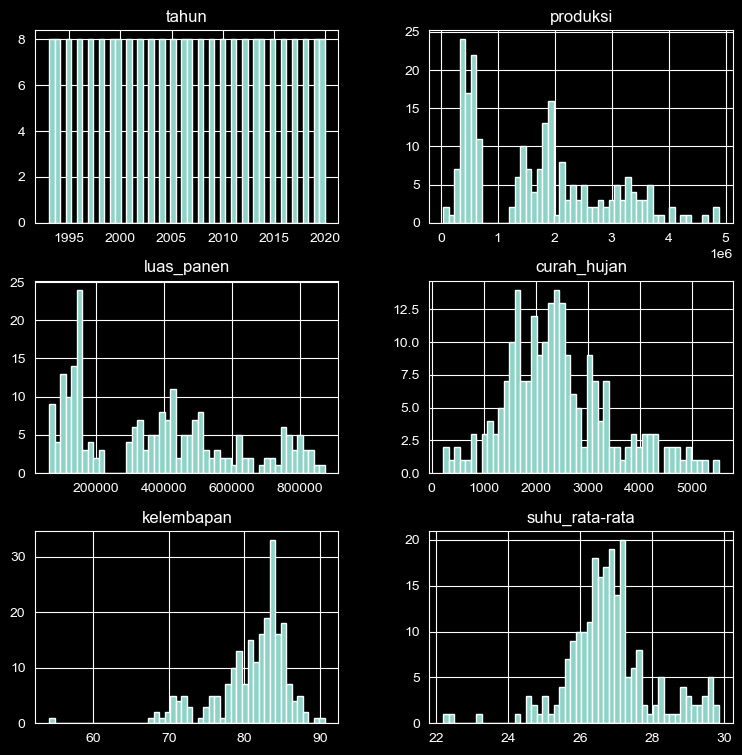

In [10]:
## DIstribution Check
data.hist(figsize=(9,9), bins=50)
plt.show()

Skewness terdeteksi, diperlukan transformasi untuk mengubah nilainya agar distribusi terlihat normal. Transformasi yang digunakan merupakan log1p(x) = log(x + 1). Log1p digunakan untuk menghindari nilai x = 0, sehingga jika terdapat x = 0, nilai transformasinya akan tetap menjadi 0 dengan log(1) = 0

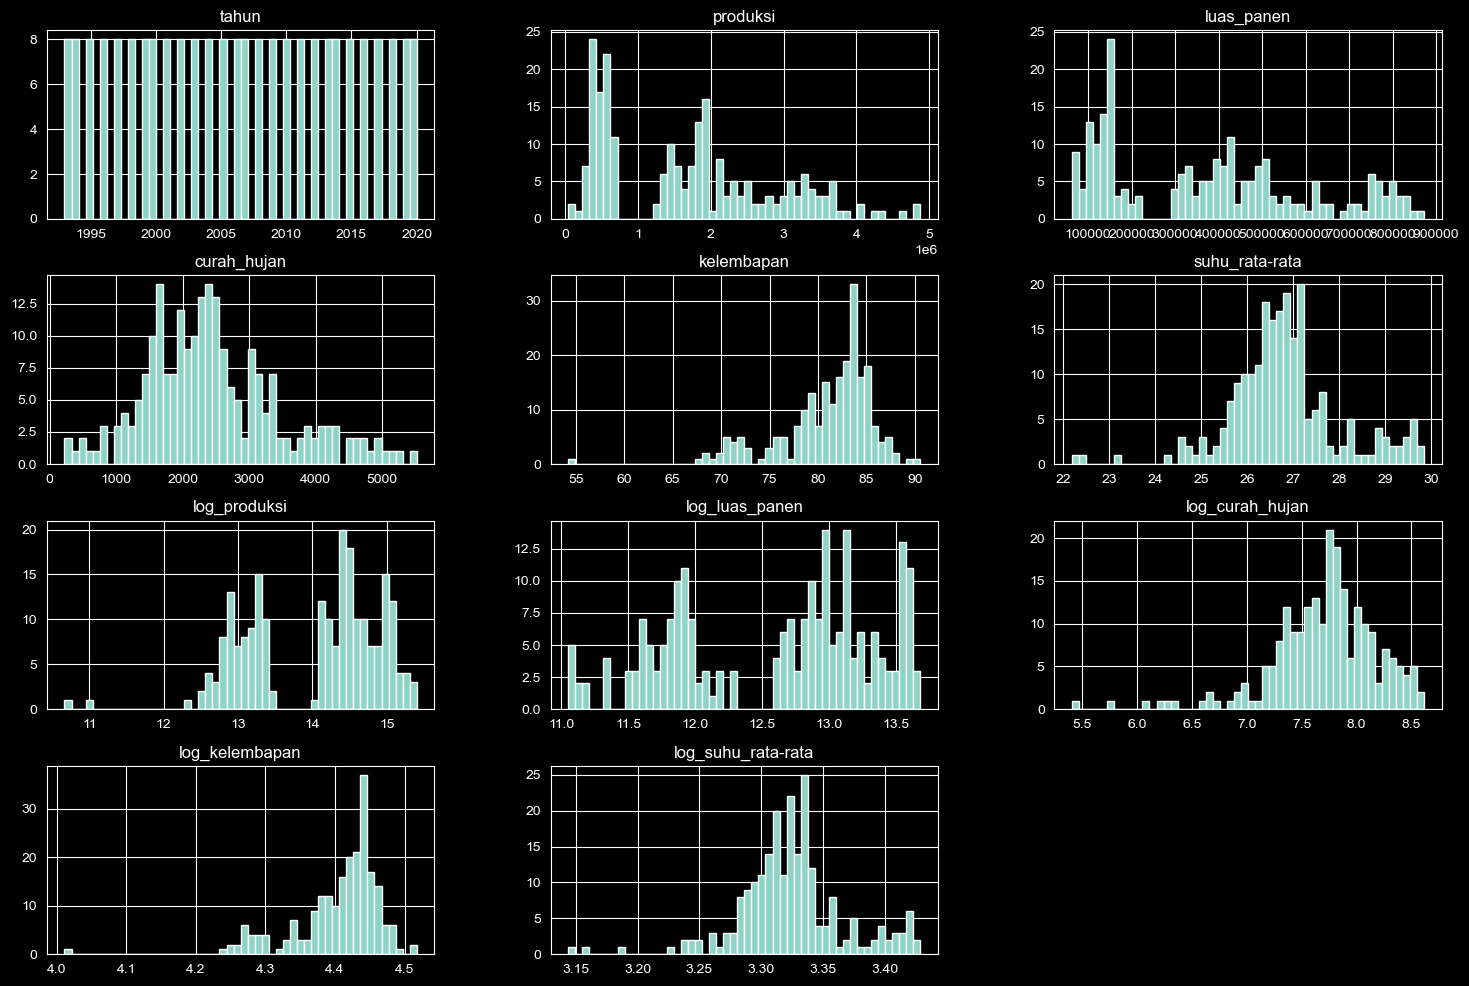

In [11]:
exclude = ["tahun", "provinsi"]

for col in [c for c in data.columns if c not in exclude]:
    data[f"log_{col}"] = np.log1p(data[col])

data.sample(5)
data.hist(figsize=(18,12), bins=50)
plt.show()

Data sudah terlihat manageable, meskipun log_produksi dan log_luas_panen bimodal. Hal tersebut kemungkinan terjadi karena terdapat wilayah provinsi yang berbeda, namun skalanya jauh lebih baik. Data log_kelembapan menunjukan sebuah nilai yang amat jauh dari distribusi normalnya. Data yang dimaksud merupakan data dengan nilai ~4.0

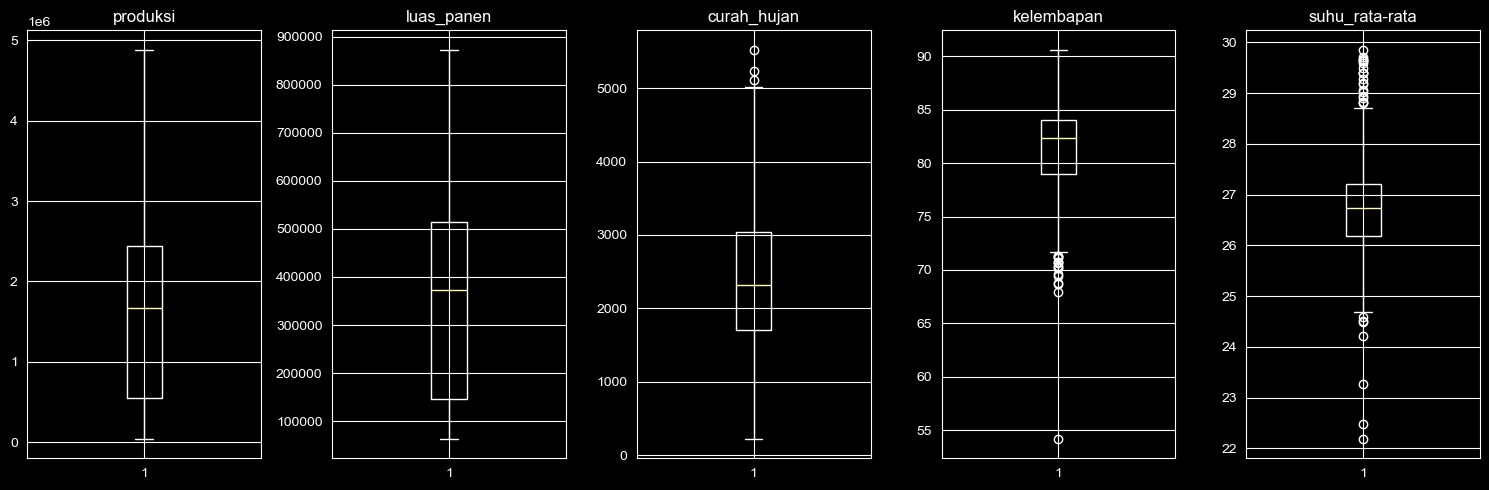

In [12]:
# Outlier Detection dengan Boxplot dan IQR
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
cols = ['produksi', 'luas_panen', 'curah_hujan', 'kelembapan', 'suhu_rata-rata']

for ax, col in zip(axes, cols):
    ax.boxplot(data[col])
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [13]:
for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = data[(data[col] < lower) | (data[col] > upper)].shape[0]
    print(f"{col}: {n_outlier} outliers")

produksi: 0 outliers
luas_panen: 0 outliers
curah_hujan: 3 outliers
kelembapan: 16 outliers
suhu_rata-rata: 28 outliers


Terdeteksi banyaknya outlier pada kolom suhu_rata-rata. Hal itu bisa saja terjadi karena suhu pada masing-masing provinsi berbeda, hal serupa dengan kelembapan dan curah_hujan. Selanjutnya kita gunakan korelasi dengan heatmap untuk melihat variabel apa saja yang mempengaruhi nilai produksi

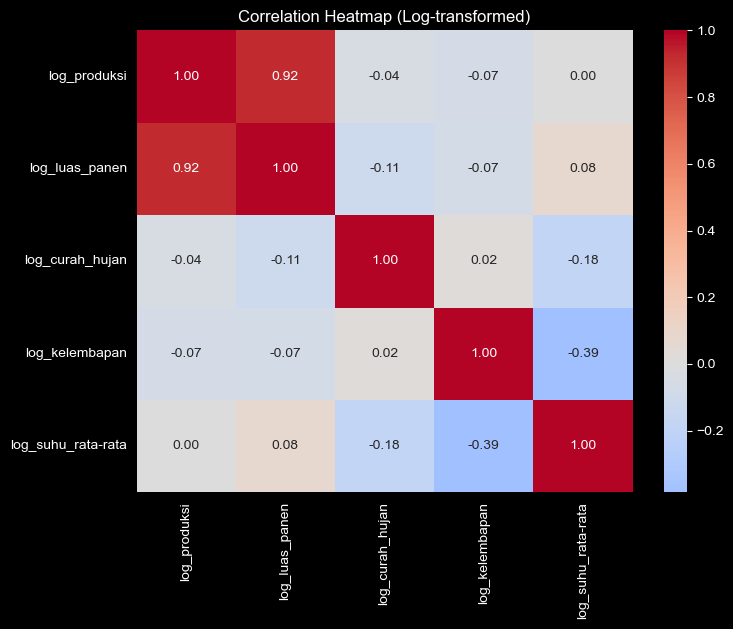

In [14]:
log_cols = [c for c in data.columns if c.startswith('log_')]

plt.figure(figsize=(8, 6))
sns.heatmap(
    data[log_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Heatmap (Log-transformed)')
plt.show()

Terlihat jelas bahwa faktor yang paling mempengaruhi nilai produksi adalah luas_panen

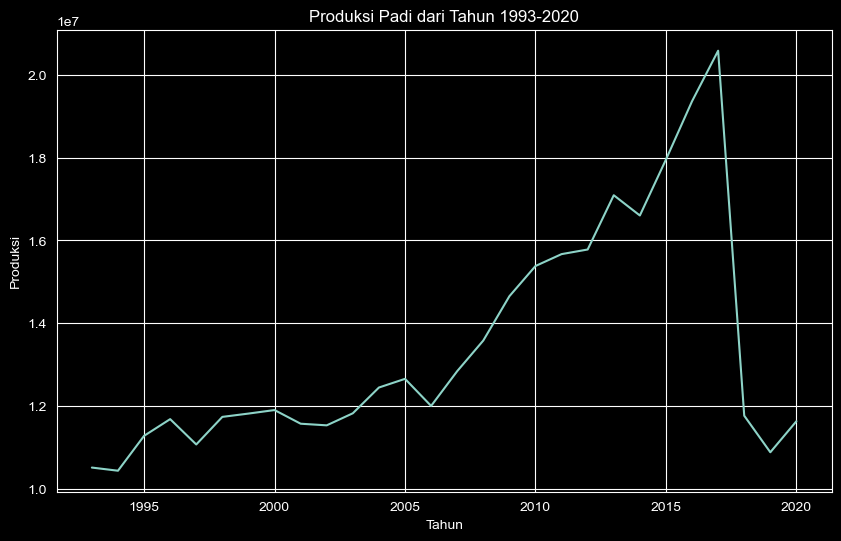

In [15]:
plt.figure(figsize=(10,6))
df.groupby('Tahun')['Produksi'].sum().plot()
plt.xlabel('Tahun')
plt.ylabel('Produksi')
plt.title('Produksi Padi dari Tahun 1993-2020')
plt.show()



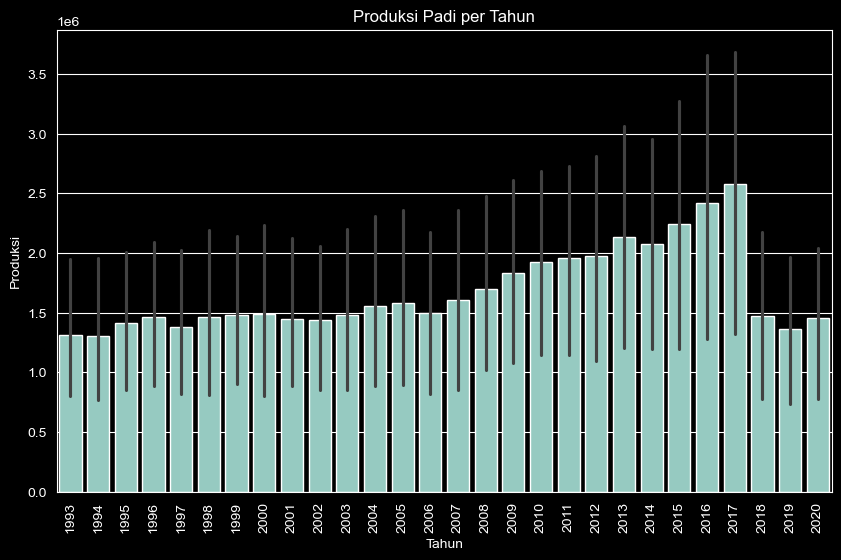

Produksi Padi per Tahun: 
 Tahun
1993    10511106.00
1994    10434879.00
1995    11277878.00
1996    11681931.00
1997    11069582.00
1998    11736390.00
1999    11816051.00
2000    11901379.00
2001    11571056.00
2002    11531731.00
2003    11823024.00
2004    12445839.00
2005    12655694.00
2006    12001280.00
2007    12841479.00
2008    13581940.00
2009    14652674.00
2010    15382976.00
2011    15670413.00
2012    15782225.00
2013    17093915.00
2014    16604009.00
2015    17956252.00
2016    19365875.90
2017    20586773.50
2018    11764423.68
2019    10881099.49
2020    11631123.08
Name: Produksi, dtype: float64


In [16]:
plt.figure(figsize=(10,6))
sns.barplot(x=df['Tahun'],y=df['Produksi'])
plt.xlabel('Tahun')
plt.xticks(rotation=90)
plt.ylabel('Produksi')
plt.title('Produksi Padi per Tahun')
plt.show()
print('Produksi Padi per Tahun: \n',df.groupby('Tahun')['Produksi'].sum())



Data menunjukkan bahwa produksi padi turun pesat ketika menginjakkan tahun 2018 dan masih stagnan hingga tahun 2020

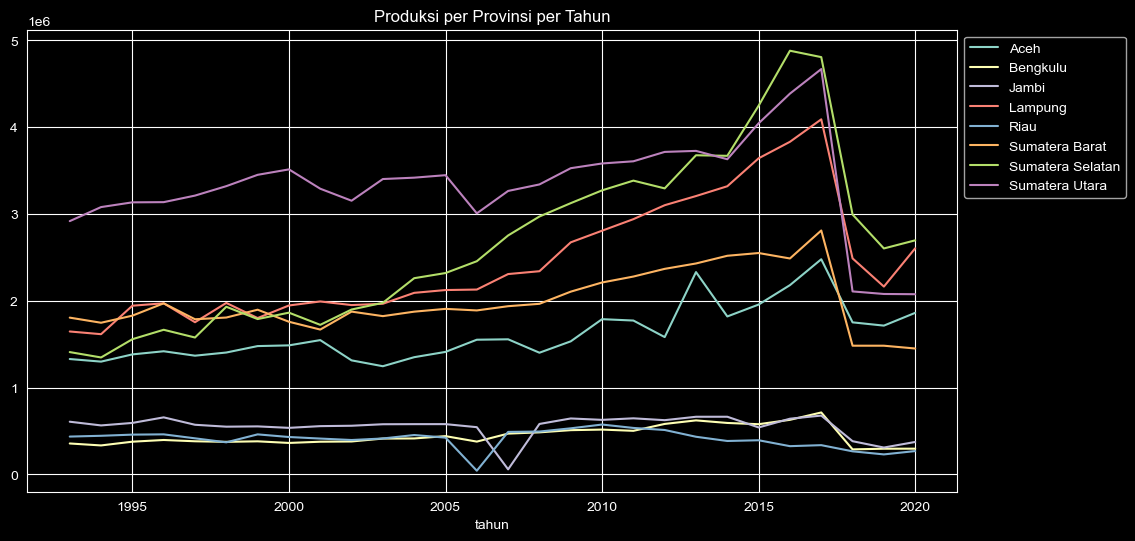

In [17]:
# Lihat per provinsi mana yang paling ngaruh ke drop
data.groupby(['tahun', 'provinsi'])['produksi'].sum().unstack().plot(figsize=(12, 6))
plt.title('Produksi per Provinsi per Tahun')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [18]:
data[data['tahun'] >= 2015].groupby('tahun')[['produksi', 'curah_hujan', 'kelembapan', 'luas_panen']].mean()

,produksi,curah_hujan,kelembapan,luas_panen
tahun,,,,
2015,2.244532e+06,2010.78750,81.88750,461121.25000
2016,2.420734e+06,2554.85000,81.79625,274593.62500
2017,2.573347e+06,2886.17500,81.93125,275097.00000
2018,1.470553e+06,1936.70375,79.70500,295975.06375
2019,1.360137e+06,2077.53750,83.72375,279416.22875
2020,1.453890e+06,2610.55000,80.86500,289029.78125


Penurunan produksi signifikan terjadi di 2018 dan dialami seluruh provinsi secara bersamaan, mengindikasikan faktor eksternal (bukan spesifik daerah). Curah hujan tidak berpengaruh pada hasil produksi, namun luas_pengurangan luas panen yang mengindikasikan penurunan hasil produksi. Jika ditinjau kembali dari korelasi, berarti ada faktor lain yang mempengaruhi tingkat produksi diluar variabel yang diolah

## Regresi Linear

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = data[['log_luas_panen']]
y = data['log_produksi']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R² : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

R² : 0.7362
RMSE: 0.4519


R² = 0.7362 → model mampu menjelaskan 73.6% variasi produksi hanya dari luas panen. Artinya, semakin luas area panen, produksi padi cenderung meningkat secara konsisten.
RMSE = 0.4519 → rata-rata error prediksi sebesar 0.45 dalam skala log. Dalam skala asli, error ini setara dengan e^0.45 ≈ 1.57x dari nilai aktual.

Model menggunakan transformasi log1p pada kedua variabel, sehingga hubungan yang dimodelkan bersifat log-log (elastisitas):
log(produksi) = β0 + β1 . log(1 + luas_panen)

Artinya: setiap kenaikan 1% luas panen, produksi naik sebesar β₁%.

Keterbatasan:

26.4% variasi produksi belum dijelaskan — kemungkinan dipengaruhi faktor yang tidak ada di dataset (kualitas benih, pupuk, kebijakan pertanian)
Model hanya single feature, belum mempertimbangkan interaksi antar variabel
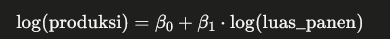

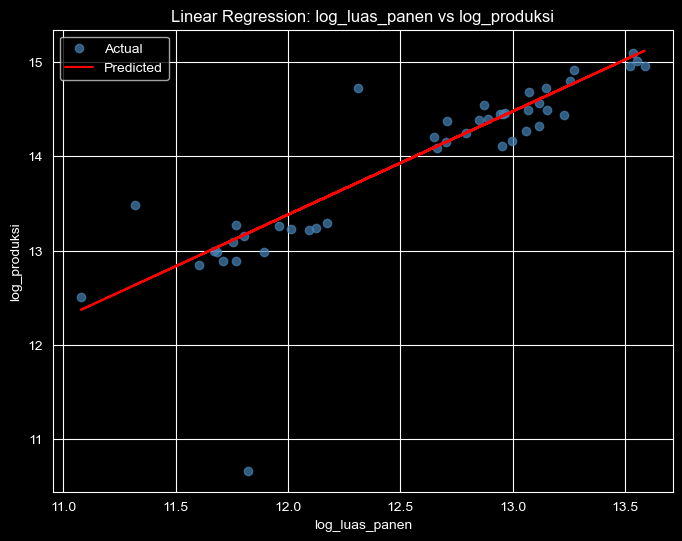

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='steelblue', label='Actual', alpha=0.7)
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('log_luas_panen')
plt.ylabel('log_produksi')
plt.title('Linear Regression: log_luas_panen vs log_produksi')
plt.legend()
plt.show()

luas_panen adalah prediktor dominan produksi padi (r = 0.92, R² = 0.74). Faktor iklim (curah hujan, kelembapan, suhu) tidak signifikan secara statistik. Penurunan produksi 2018 berkorelasi dengan penurunan luas panen secara nasional.